<a href="https://colab.research.google.com/github/dtoralg/TheValley_MDS/blob/main/%5B06%5D%20-%20Workshop%20Clustering/Workshop_Clustering_Spotify_ENUNCIADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Workshop · Clustering end-to-end con Spotify

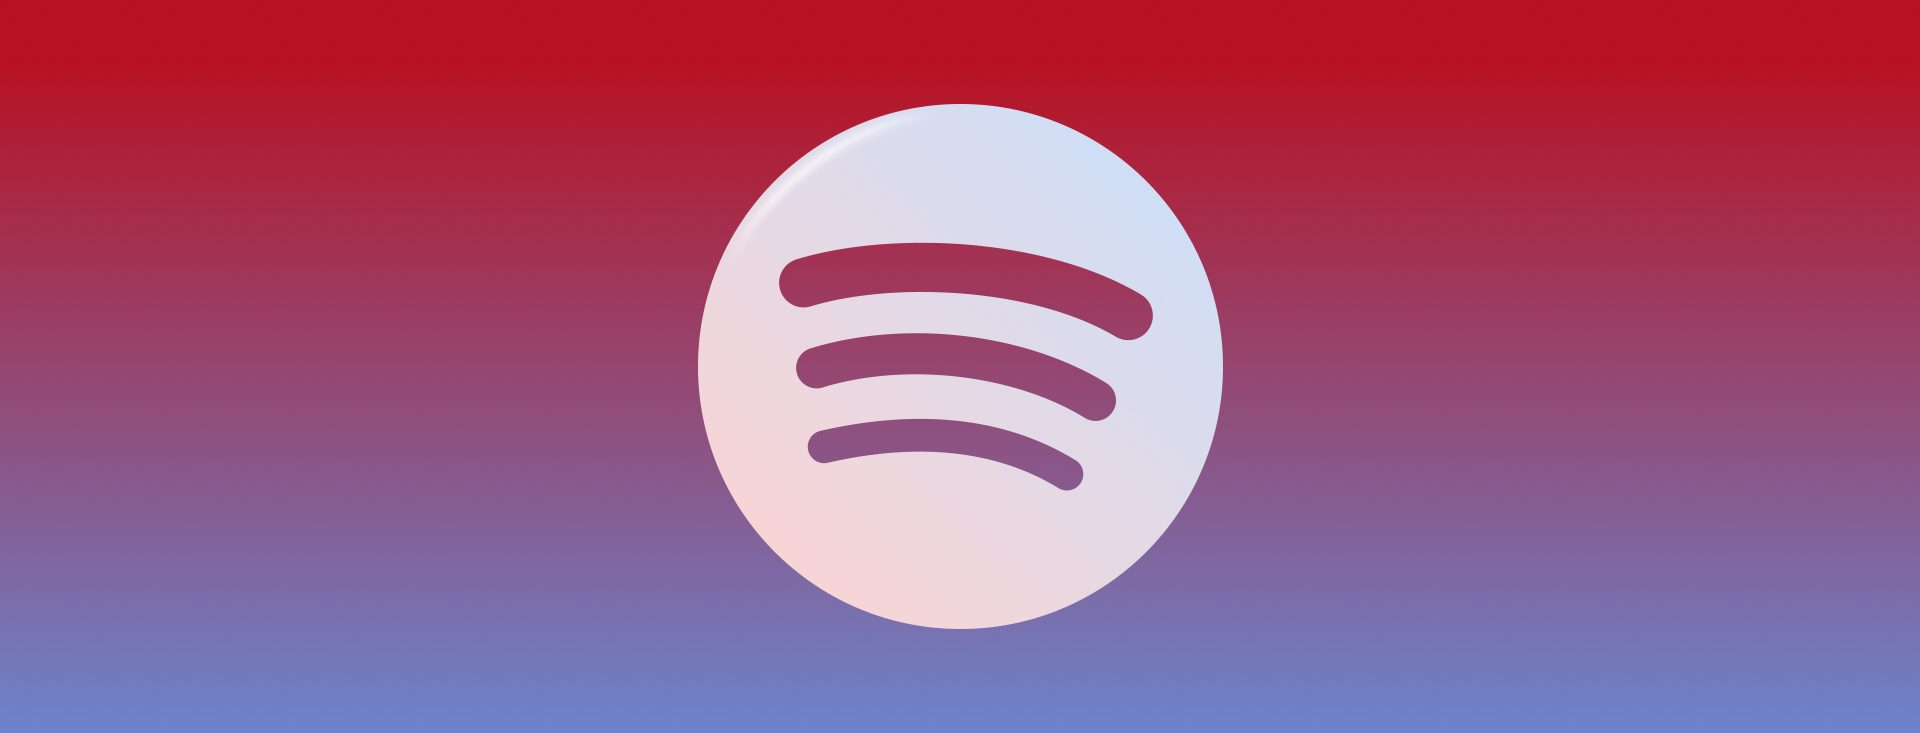

## El encargo

Sois el equipo de Data Science de Spotify. Producto quiere lanzar **playlists automáticas por tipo de canción**, sin etiquetar nada a mano. Piden tres entregables:

1. **Una segmentación del catálogo**: grupos de canciones que se parecen entre sí, con método y número de grupos justificados.
2. **Una ficha de segmentos**: qué es cada grupo, un nombre que producto entienda y una acción por grupo.
3. **Un mecanismo de asignación**: mañana entran canciones nuevas al catálogo y hay que colocarlas en su segmento sin reentrenar nada.

No hay target: nadie os dirá cuáles son los grupos "correctos". Esto es **aprendizaje no supervisado** de principio a fin.


## El plan de trabajo de ML no supervisado (guárdatelo)

Este plan sirve para **cualquier proyecto no supervisado**: segmentar clientes, detectar anomalías, agrupar productos, u otros usos.

| # | Fase | Pregunta que respondes | Entregable |
|---|------|------------------------|------------|
| 1 | Problema de negocio | ¿Qué decisión va a tomar alguien con esto? | Objetivo + unidad de análisis (aquí: la canción) |
| 2 | EDA | ¿Qué datos tengo y en qué estado están? | Lista de problemas y decisiones sobre los datos |
| 3 | Ingeniería de variables | ¿Qué variables entran al modelo y en qué forma? | Matriz de datos limpia, transformada y **escalada** |
| 4 | Reducción de dimensión | ¿Puedo comprimir sin perder señal? ¿Cómo se ven mis datos? | Nº de componentes + visualización 2D (PCA) |
| 5 | Modelado | ¿Qué algoritmo y cuántos grupos? | Modelos + K justificado (codo, silhouette, dendrograma...) |
| 6 | Comparación | ¿Qué solución es mejor **para este caso**? | Modelo elegido y por qué |
| 7 | Profiling | ¿Qué es cada grupo y qué hacemos con él? | Ficha de segmentos: nombre + acción |
| 8 | Activación | ¿Cómo lo usa el producto mañana? | Asignación de datos nuevos (aquí: KNN) |

Cambiar el orden es la fuente de errores más habitual.


## Cómo funciona el workshop

- **2,5 horas, 6 fases.** Cada fase tiene un tiempo orientativo y termina en un **✅ Checkpoint**: unas preguntas de control para decidir si puedes cerrar la fase y avanzar.
- El código lo escribes tú: aquí solo hay estructura, tareas y preguntas. Buscar en la documentación (o en tus notebooks de clase) es parte del ejercicio.
- Si vas justo de tiempo, **cierra la fase y avanza**: es mejor un end-to-end completo que una fase perfecta.


---
# Fase 0 · Setup y datos (10 min)


In [ ]:
# TODO: importa las librerías que vas a necesitar a lo largo del workshop
# (pandas, numpy, visualización, y lo que uses de sklearn / scipy)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Configuración recomendada
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [ ]:
# Dataset de Spotify: 114.000 canciones con features de audio.
# Si la descarga remota falla, baja el zip a mano y lee desde local.
DATA_URL = "https://drive.google.com/uc?export=download&id=1a9pA0dFbwVH2i6UZjgwcicvcD_SCmG3I"

df_full = pd.read_csv(DATA_URL, compression="zip")
df_full.head(3)


In [ ]:
# Preparación del terreno:
# - la misma canción aparece repetida en varios géneros -> una por track_id
# - trabajamos con una muestra de 5.000 canciones
# - reservamos 500 canciones "que llegarán mañana al catálogo": NO las toques hasta la Fase 6
df_full = (df_full
           .drop(columns=["Unnamed: 0"])
           .drop_duplicates(subset="track_id")
           .dropna()
           .reset_index(drop=True))

muestra = df_full.sample(n=5500, random_state=RANDOM_STATE)
df_work = muestra.iloc[:5000].reset_index(drop=True)   # tu dataset de trabajo
df_new  = muestra.iloc[5000:].reset_index(drop=True)   # canciones nuevas para la Fase 6

print(f"Catálogo: {df_full.shape[0]} | df_work: {df_work.shape} | df_new: {df_new.shape}")


### Diccionario de datos

| Columna | Qué es |
|---|---|
| `track_id`, `track_name`, `artists`, `album_name` | Identificadores y texto |
| `popularity` | Popularidad 0-100 (calculada por Spotify) |
| `duration_ms` | Duración en milisegundos |
| `explicit` | Contenido explícito (True/False) |
| `danceability`, `energy`, `valence` | Cómo de bailable, enérgica y "alegre" suena (0-1) |
| `acousticness`, `instrumentalness`, `speechiness`, `liveness` | Prob. de ser acústica, instrumental, hablada, en directo (0-1) |
| `loudness` | Volumen medio en dB (negativo: cuanto más cerca de 0, más fuerte) |
| `tempo` | Velocidad en BPM |
| `key`, `mode`, `time_signature` | Tonalidad (0-11), modo mayor/menor, compás |
| `track_genre` | Género asignado a la pista |


---
# Fase 1 · EDA e ingeniería de variables (25 min)

**Objetivo:** decidir qué variables entran al clustering y dejarlas listas en una matriz escalada.

### Tareas
1. Explora `df_work`: tipos, descriptivo, distribuciones, correlaciones.
2. Decide qué variables entran al clustering y cuáles quedan fuera (y por qué).
3. Transforma lo que lo necesite (recuerda IV I: colas largas, variables circulares...).
4. Escala las variables. Guarda el escalador: lo vas a reutilizar en la Fase 6.

### Preguntas guía
- ¿Qué columnas son identificadores o texto que no deben entrar?
- ¿Debe entrar `popularity`? ¿Describe cómo **suena** la canción o cómo le **fue**?
- ¿Y `track_genre`? ¿Qué pasa si agrupas usando (casi) un target?
- ¿Qué variables tienen escalas muy distintas o colas largas?


In [ ]:
# TODO: desarrolla aquí tu EDA


In [ ]:
# TODO: selecciona tus variables, transforma lo necesario y escala


### Mini reflexión
Responde brevemente en markdown:

- ¿Qué variables has dejado fuera y por qué?
- ¿Qué le pasaría a la distancia entre dos canciones si no escalas?

#### Respuesta:


...

### ✅ Checkpoint de fase
Antes de avanzar:
- ¿Tienes una lista clara de variables que entran (y sabrías defender cada exclusión)?
- ¿Has tratado las colas largas?
- ¿Tu matriz está escalada y sin nulos?
- ¿Has guardado el escalador para reutilizarlo con datos nuevos?


---
# Fase 2 · PCA: mira tus datos (15 min)

Tienes ~10 dimensiones y los ojos solo soportan 2. Usa PCA para dos cosas:

### Tareas
1. Ajusta un PCA sobre tus datos escalados y mira la **varianza explicada** por componente y acumulada. ¿Cuántas componentes necesitas para el 90%?
2. Proyecta las canciones en **2D** y píntalas (son 5.000 puntos: tamaño pequeño y transparencia).

### Preguntas guía
- ¿Por qué hay que escalar antes de PCA?
- ¿Qué mezcla la primera componente? (mira los pesos si te atreves)


In [ ]:
# TODO: PCA, varianza explicada y proyección 2D


### Mini reflexión

- ¿Cuánta varianza conservas en 2D? ¿Es este mapa una foto fiel o un resumen con pérdida?
- ¿Se ven grupos separados o una nube continua? ¿Demuestra eso que no hay clusters?

#### Respuesta:


### ✅ Checkpoint de fase
- ¿Sabes cuántas componentes hacen falta para el 90% de la varianza?
- ¿Tienes la proyección 2D pintada? La vas a reutilizar para colorear los clusters.


---
# Fase 3 · Primer modelo: K-Means (25 min)

Entrenar K-Means son dos líneas; la decisión importante es **elegir K**. Vas a combinar:

- **Codo**: dónde la inercia deja de bajar con ganas.
- **Silhouette**: cómo de bien asignado está cada punto (-1 a 1).
- **Negocio**: ¿cuántos segmentos puede accionar producto de verdad?

Ninguno de los tres manda solo.

### Tareas
1. Entrena K-Means para un rango de K con `k-means++`, y pinta codo y silhouette.
2. Elige tu K y entrena el modelo final.
3. Pinta los clusters sobre tu proyección PCA 2D.


In [ ]:
# TODO: evalúa varios K con codo y silhouette


In [ ]:
# TODO: elige tu K, entrena el modelo final y pinta los clusters sobre el PCA


### Mini reflexión

- ¿El codo y el silhouette apuntan al mismo K? Si no, ¿con qué criterio desempatas?
- Si el silhouette máximo sale en un K muy bajo, ¿por qué podría aun así no ser la mejor entrega para producto?

#### Respuesta:


### ✅ Checkpoint de fase
- ¿Has probado varios K, no solo uno?
- ¿Has elegido tu K y sabrías defenderlo en una frase (métrica + negocio)?
- ¿Tienes el modelo final entrenado y los clusters pintados sobre el PCA?

Las fases siguientes usan estas etiquetas: si algo cojea, arréglalo ahora.



---
## ☕ Descanso



---
# Fase 4 · Segundo modelo (25 min)

K-Means asume grupos compactos y "redondos". Ponlo a prueba con un retador. **Elige al menos uno** (los tres si vas sobrado):

| Opción | Modelo | Para qué brilla | Aviso práctico |
|---|---|---|---|
| A | **Jerárquico (ward)** | El dendrograma te deja ver la estructura y cortar donde tenga sentido | Es O(n²): puede que necesites subsamplear |
| B | **DBSCAN** | Formas irregulares y detección de ruido (canciones "inclasificables") | En 10 dimensiones las distancias se difuminan: prueba también sobre las primeras componentes del PCA |
| C | **K-Medoids** | El centro de cada grupo es una **canción real** que puedes escuchar | `!pip install kmedoids`; funciona con matriz de distancias precalculada, usa una submuestra |

### Tareas
1. Entrena tu retador y optimiza sus parámetros (corte del dendrograma, `eps` y `min_samples`, K...).
2. Compáralo con K-Means: silhouette, número de grupos, % de ruido si aplica... y tu valoración cualitativa.

⚠️ Juego limpio: el silhouette solo es comparable **sobre los mismos datos y el mismo espacio**. Si usas submuestra o PCA, dilo en tu conclusión. En DBSCAN, calcula el silhouette sin los puntos de ruido (etiqueta -1) e indica el % de ruido.


In [ ]:
# TODO: entrena y optimiza tu retador (A, B o C)


In [ ]:
# TODO: compara K-Means vs tu retador
# ¿Se te ocurren más formas de compararlos, además del silhouette?


### Mini reflexión

- ¿Tu retador ha encontrado una estructura distinta a la de K-Means o básicamente la misma?
- ¿En qué caso de negocio preferirías DBSCAN? ¿Y K-Medoids?

#### Respuesta:


### ✅ Checkpoint de fase
- ¿Has entrenado y optimizado al menos un retador?
- ¿Tienes una comparación honesta con K-Means (mismos datos y mismo espacio, o avisándolo)?
- ¿Has decidido con qué modelo sigues a la Fase 5 y por qué?


---
# Fase 5 · Profiling: de números a segmentos (20 min)

Aquí el clustering deja de ser un gráfico y empieza a tener valor. Aplica el profiling en 4 pasos de la clase de Análisis Cluster:

1. **Perfil** de cada grupo: media por variable, sobre las variables ORIGINALES.
2. **Índice vs media global**: divide el perfil de cada grupo entre la media del catálogo. Un 2.0 = "el doble que la media".
3. **Tamaño** de cada grupo: ¿es un segmento o una anécdota?
4. **Nombre y acción**: el entregable de verdad.

Guardaste `track_genre` y `popularity` fuera del modelo: úsalas ahora como **validación externa**. ¿Los géneros dominantes de cada cluster cuadran con su perfil?

⚠️ Ojo con `loudness`: es negativa (dB), su índice se lee al revés (más alto = MÁS silenciosa).


In [ ]:
# TODO: desarrolla aquí tu estrategia de profiling


In [ ]:
# TODO: validación externa con lo que apartaste
# ¿Qué géneros dominan cada cluster? ¿Qué popularidad media tiene cada uno?


### Tu ficha de segmentos
Rellena en markdown, un segmento por línea: **nombre** (que producto entienda, nada de "Cluster 0") **+ rasgo principal + una acción de producto**.

- Segmento ...: ...
- Segmento ...: ...


### ✅ Checkpoint de fase
- ¿Tienes el perfil y el índice de cada cluster (y los tamaños)?
- ¿La validación externa (géneros) cuadra con los perfiles?
- ¿Cada segmento tiene nombre y una acción? Este es el entregable nº 2 del encargo.


---
# Fase 6 · De cluster a producto: KNN (15 min)

El clustering está entregado... pero mañana entran canciones nuevas al catálogo y hay que asignarlas a un segmento **sin reentrenar nada**. Conecta con la clase de KNN (eager vs lazy): KNN memoriza el catálogo etiquetado y, cuando llega una canción nueva, mira sus K vecinos y vota.

Fíjate en el patrón: el clustering (no supervisado) ha **creado las etiquetas** que ahora un clasificador (supervisado) aprende a asignar. Se usa muchísimo en proyectos reales.

### Tareas
1. Prepara `df_new` (las 500 canciones de la Fase 0) con **exactamente la misma receta** de features que `df_work`. Piensa: ¿el escalador se vuelve a ajustar o se reutiliza? ¿Por qué?
2. Entrena un KNN con tus datos escalados y tus etiquetas de cluster, y asigna segmento a las canciones nuevas.
3. Sanity check: compara la asignación del KNN con la del centroide más cercano (`.predict()` del K-Means). ¿% de acuerdo?

### Extra ⭐ (si vas bien de tiempo): tu recomendador
Con `NearestNeighbors` sobre TODO el catálogo (`df_full`, misma receta de features): busca una canción que te guste por nombre y saca sus 10 vecinas más cercanas. Tu playlist automática. ¿La pondrías en tu Spotify?


In [ ]:
# TODO: prepara df_new y asigna segmento con KNN


In [ ]:
# TODO (extra): tu recomendador "dame 10 parecidas"


### Mini reflexión

- Tu recomendador solo usa features de audio. ¿Qué le falta frente al recomendador real de Spotify?

#### Respuesta:


### ✅ Checkpoint de fase
- ¿Las canciones nuevas pasaron por la MISMA receta de features (sin volver a ajustar el escalador)?
- ¿Cada canción nueva tiene un segmento asignado?
- ¿El acuerdo con la asignación por centroide te parece razonable? Este es el entregable nº 3.


---
# Bonus con IA · Ponles nombre con un LLM (opcional final de clase)

Los nombres de la Fase 5 los pusiste tú. Deja que un LLM proponga los suyos **a partir de tu tabla de perfiles** y compara: buen ejemplo de clustering + IA generativa (el modelo no ve las canciones, solo tu resumen agregado).

Toma tu API key gratuita de [OpenRouter](https://openrouter.ai/settings/keys). Si no tienes key, imprime el prompt y pégalo en cualquier chat de IA.


In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="TU-API-KEY"
)

# ¿Cómo le pasas tus perfiles al modelo? Construye el prompt con tu tabla de la Fase 5
# (pista: un DataFrame se convierte en texto con .to_string())

response = client.chat.completions.create(
    model="openrouter/free",
    messages=[
        {"role": "user", "content": " XXX "}
    ]
)

print(response.choices[0].message.content)


---
# Cierre del workshop

### Preguntas finales
1. De las 8 fases del plan de trabajo, ¿cuál te ha llevado más tiempo? ¿Cuál llevaría más tiempo en un proyecto real?
2. ¿Qué harías distinto si en vez de canciones fueran clientes de un banco? ¿Qué cambia y qué no cambia del plan?
3. Si el silhouette "prefería" un K distinto al que entregaste, ¿cómo lo defiendes ante un perfil técnico?
4. ¿Qué habría que monitorizar si este sistema (clustering + KNN) se pone en producción de verdad?

### Takeaways
- El plan de trabajo no supervisado es siempre el mismo: datos -> features escaladas -> (PCA) -> modelo + K justificado -> profiling -> activación.
- Las métricas (codo, silhouette) orientan pero no deciden: el K final se defiende con números + interpretabilidad + acción.
- Cada algoritmo asume una forma de grupo: K-Means (compactos), jerárquico (árbol interpretable), DBSCAN (densidad + ruido), K-Medoids (centros reales).
- El profiling es el entregable: un cluster sin nombre y sin acción no genera valor.
- El ciclo se cierra en producción: el clustering crea etiquetas y un clasificador (KNN) las asigna a datos nuevos, con la misma receta de features y sin fugas.
